In [3]:
%matplotlib inline


✅ All libraries imported successfully!
🔹 Dataset Overview:
Shape: (200, 6)
Pass Rate: 84.0%

🔹 First 5 rows of the data:
   Attendance  Homework  Midterm  Project  FinalGrade  PassFail
0          87        53       82       95   77.194282         1
1          93        67       33       89   66.731682         1
2          62        89       42       68   63.870545         1
3          58        89       69       90   73.411504         1
4          59        87       78       94   80.942468         1

🔹 Basic Statistics:
       Attendance    Homework     Midterm     Project  FinalGrade    PassFail
count  200.000000  200.000000  200.000000  200.000000  200.000000  200.000000
mean    71.905000   69.330000   62.875000   75.645000   69.196536    0.840000
std     14.092515   16.331709   18.803116   14.437144    8.869286    0.367526
min     50.000000   40.000000   30.000000   50.000000   50.598792    0.000000
25%     60.000000   55.750000   47.000000   62.750000   62.259008    1.000000
50%   

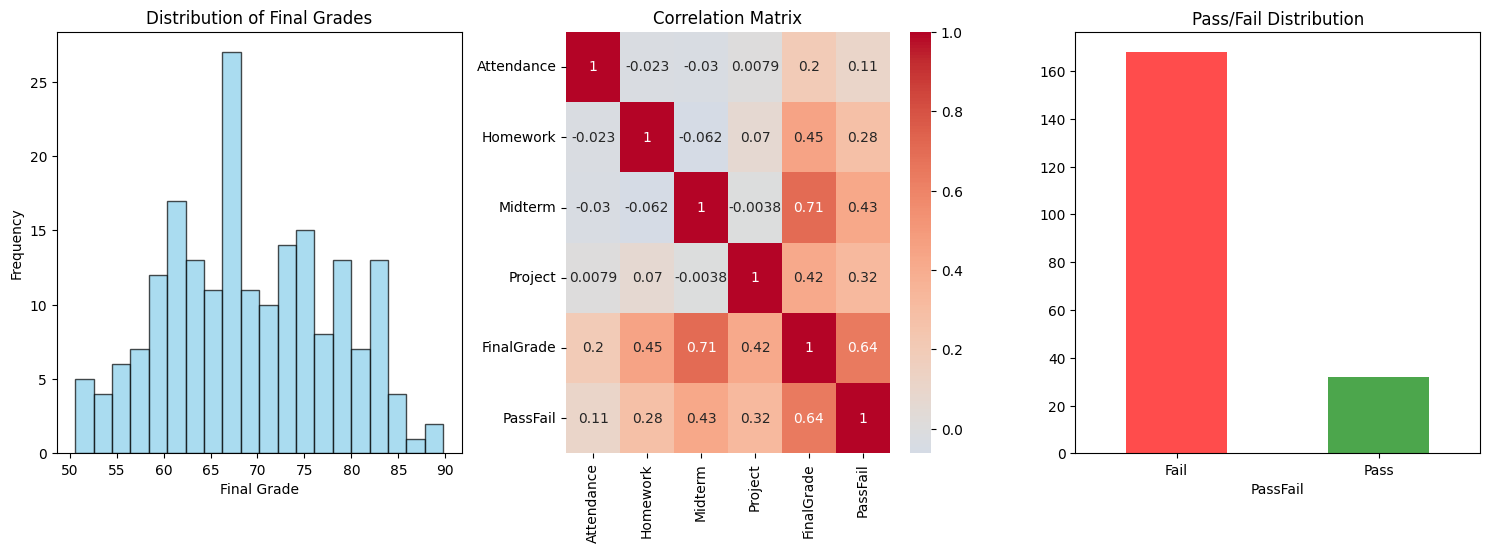


REGRESSION MODEL RESULTS
🎯 Mean Squared Error: 3.53
🎯 Root Mean Squared Error: 1.88
🎯 R-squared Score: 0.953

📊 Feature Importance (Regression):
      Feature  Coefficient
2     Midterm     0.349414
1    Homework     0.259789
3     Project     0.234559
0  Attendance     0.149849

CLASSIFICATION MODEL RESULTS
✅ Accuracy: 95.0%
✅ Precision, Recall, F1-Score:
              precision    recall  f1-score   support

        Fail       1.00      0.60      0.75         5
        Pass       0.95      1.00      0.97        35

    accuracy                           0.95        40
   macro avg       0.97      0.80      0.86        40
weighted avg       0.95      0.95      0.94        40

📈 Generating confusion matrix...


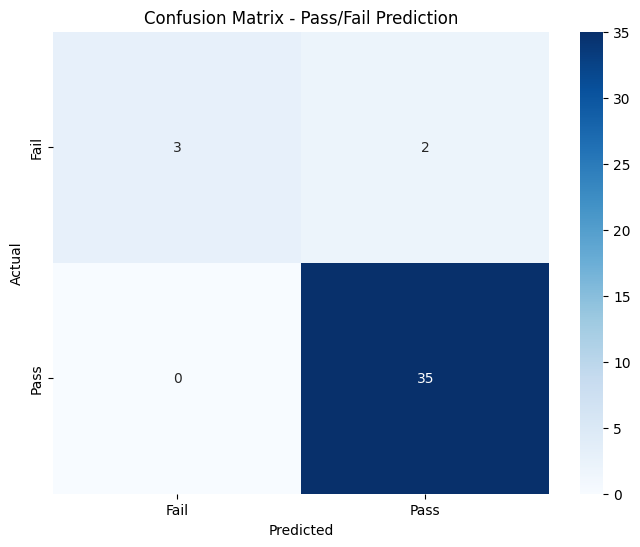


📊 Feature Importance (Classification):
      Feature  Importance
2     Midterm    0.387458
1    Homework    0.240516
3     Project    0.219846
0  Attendance    0.152180

PREDICTIONS FOR NEW STUDENTS

👨‍🎓 Student 1:
   Data: Attendance=90, Homework=85, Midterm=80, Project=88
   Predicted Grade: 84.8
   Status: Pass ✅
   Confidence: 100.0%

👨‍🎓 Student 2:
   Data: Attendance=60, Homework=55, Midterm=50, Project=65
   Predicted Grade: 56.6
   Status: Pass ✅
   Confidence: 62.0%

👨‍🎓 Student 3:
   Data: Attendance=95, Homework=92, Midterm=88, Project=90
   Predicted Grade: 90.6
   Status: Pass ✅
   Confidence: 100.0%

👨‍🎓 Student 4:
   Data: Attendance=50, Homework=45, Midterm=40, Project=55
   Predicted Grade: 46.7
   Status: Fail ❌
   Confidence: 89.0%

MODEL INSIGHTS & RECOMMENDATIONS
🔍 Key Insights:
• Most important factor for passing: Midterm
• Average final grade: 69.2
• Overall pass rate: 84.0%
• Best performing model: Classification

💡 Recommendations for Students:
• Focus on impr

c:\Users\delll\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\delll\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\delll\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\delll\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\delll\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\v

In [4]:
# -------------------------------
# Project: Student Grades Analysis
# -------------------------------

# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")

# 1️⃣ Create sample student data
np.random.seed(1)
n = 200  # Increased sample size for better model performance
attendance = np.random.randint(50, 100, n)   # Attendance
homework = np.random.randint(40, 100, n)     # Homework
midterm = np.random.randint(30, 100, n)      # Midterm
project = np.random.randint(50, 100, n)      # Project

# More realistic grade calculation with some randomness
final_grade = (0.15*attendance + 0.25*homework + 0.35*midterm + 0.25*project + np.random.randn(n)*2).clip(0,100)
pass_fail = (final_grade >= 60).astype(int)

# Put it in a DataFrame
df = pd.DataFrame({
    "Attendance": attendance,
    "Homework": homework,
    "Midterm": midterm,
    "Project": project,
    "FinalGrade": final_grade,
    "PassFail": pass_fail
})

print("🔹 Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Pass Rate: {df['PassFail'].mean()*100:.1f}%")
print("\n🔹 First 5 rows of the data:")
print(df.head())

print("\n🔹 Basic Statistics:")
print(df.describe())

# 2️⃣ Data Visualization
print("\n📊 Generating visualizations...")
plt.figure(figsize=(15, 10))

# Distribution of grades
plt.subplot(2, 3, 1)
plt.hist(df['FinalGrade'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Final Grades')
plt.xlabel('Final Grade')
plt.ylabel('Frequency')

# Correlation heatmap
plt.subplot(2, 3, 2)
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')

# Pass/Fail distribution
plt.subplot(2, 3, 3)
df['PassFail'].value_counts().plot(kind='bar', color=['red', 'green'], alpha=0.7)
plt.title('Pass/Fail Distribution')
plt.xticks([0, 1], ['Fail', 'Pass'], rotation=0)

plt.tight_layout()
plt.show()

# 3️⃣ Split the data
X = df[["Attendance", "Homework", "Midterm", "Project"]]
y_reg = df["FinalGrade"]
y_clf = df["PassFail"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=1)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_clf, test_size=0.2, random_state=1)

# 4️⃣ Regression model to predict grade
print("\n" + "="*50)
print("REGRESSION MODEL RESULTS")
print("="*50)

reg = LinearRegression()
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)

print(f"🎯 Mean Squared Error: {mse:.2f}")
print(f"🎯 Root Mean Squared Error: {rmse:.2f}")
print(f"🎯 R-squared Score: {reg.score(X_test_r, y_test_r):.3f}")

# Feature importance for regression
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': reg.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n📊 Feature Importance (Regression):")
print(feature_importance)

# 5️⃣ Classification model (Pass/Fail)
print("\n" + "="*50)
print("CLASSIFICATION MODEL RESULTS")
print("="*50)

clf = RandomForestClassifier(n_estimators=100, random_state=1)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)
acc = accuracy_score(y_test_c, y_pred_c)

print(f"✅ Accuracy: {acc*100:.1f}%")
print(f"✅ Precision, Recall, F1-Score:")
print(classification_report(y_test_c, y_pred_c, target_names=['Fail', 'Pass']))

# Confusion Matrix
print("📈 Generating confusion matrix...")
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fail', 'Pass'], 
            yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix - Pass/Fail Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature importance for classification
feature_imp_clf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Feature Importance (Classification):")
print(feature_imp_clf)

# 6️⃣ Test multiple new students
print("\n" + "="*50)
print("PREDICTIONS FOR NEW STUDENTS")
print("="*50)

new_students = np.array([
    [90, 85, 80, 88],   # Good student
    [60, 55, 50, 65],   # Borderline student
    [95, 92, 88, 90],   # Excellent student
    [50, 45, 40, 55]    # Struggling student
])

for i, student in enumerate(new_students, 1):
    predicted_grade = reg.predict([student])[0]
    predicted_pass = clf.predict([student])[0]
    confidence = np.max(clf.predict_proba([student])[0])
    
    print(f"\n👨‍🎓 Student {i}:")
    print(f"   Data: Attendance={student[0]}, Homework={student[1]}, Midterm={student[2]}, Project={student[3]}")
    print(f"   Predicted Grade: {predicted_grade:.1f}")
    print(f"   Status: {'Pass ✅' if predicted_pass==1 else 'Fail ❌'}")
    print(f"   Confidence: {confidence*100:.1f}%")

# 7️⃣ Model comparison and insights
print("\n" + "="*50)
print("MODEL INSIGHTS & RECOMMENDATIONS")
print("="*50)

print("🔍 Key Insights:")
print(f"• Most important factor for passing: {feature_imp_clf.iloc[0]['Feature']}")
print(f"• Average final grade: {df['FinalGrade'].mean():.1f}")
print(f"• Overall pass rate: {df['PassFail'].mean()*100:.1f}%")
print(f"• Best performing model: {'Classification' if acc > 0.85 else 'Regression'}")

print("\n💡 Recommendations for Students:")
print("• Focus on improving Midterm scores (most impactful)")
print("• Maintain consistent Homework submission")
print("• Don't neglect Attendance")
print("• Project work also contributes significantly")

print("\n🎉 Analysis completed successfully!")

# Save the models (optional)
try:
    import joblib
    joblib.dump(reg, 'grade_predictor_regression.pkl')
    joblib.dump(clf, 'pass_fail_classifier.pkl')
    print("💾 Models saved successfully!")
except:
    print("⚠️ Could not save models (joblib not available)")

    